In [40]:
import pandas as pd

# Define the path to your GFF file
gff_file = 'data/A.Thaliana/Arabidopsis_thaliana.TAIR10.57.gff3'

# Read the GFF file into a pandas DataFrame
# We assume the GFF file has no header and use tab as the delimiter
df = pd.read_csv(gff_file, sep='\t', comment='#', header=None)

# Assign column names to the DataFrame
df.columns = ['chr', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']

/tmp/ipykernel_1351737/711872405.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(gff_file, sep='\t', comment='#', header=None)


In [41]:
def attributes_to_dict(attributes):
    attr_dict = {}
    for attribute in attributes.split(';'):
        key_value = attribute.split('=')
        if len(key_value) == 2:
            key, value = key_value
            attr_dict[key] = value
    return attr_dict

df['attributes'] = df['attributes'].apply(attributes_to_dict)

df['chr'] = df['chr'].astype(str) # Convert the 'chr' column to string
# replace chr value with 'chr' + value
df['chr'] = 'chr' + df['chr']

In [7]:
df.head()

,chr,source,type,start,end,score,strand,phase,attributes
0,1,TAIR10,chromosome,1,30427671,.,.,.,"{'ID': 'chromosome:1', 'Alias': 'Chr1,CP002684..."
1,1,araport11,gene,3631,5899,.,+,.,"{'ID': 'gene:AT1G01010', 'Name': 'NAC001', 'bi..."
2,1,araport11,mRNA,3631,5899,.,+,.,"{'ID': 'transcript:AT1G01010.1', 'Parent': 'ge..."
3,1,araport11,five_prime_UTR,3631,3759,.,+,.,{'Parent': 'transcript:AT1G01010.1'}
4,1,araport11,exon,3631,3913,.,+,.,"{'Parent': 'transcript:AT1G01010.1', 'Name': '..."


In [66]:
# cuantos tipos de anotacines hay?
annotated_types = df['type'].value_counts()
print(annotated_types)

type
exon               313952
CDS                286067
five_prime_UTR      56384
mRNA                48359
three_prime_UTR     48308
gene                27655
ncRNA_gene           5178
lnc_RNA              3879
tRNA                  689
ncRNA                 377
miRNA                 325
snoRNA                287
snRNA                  82
rRNA                   15
chromosome              7
Name: count, dtype: int64


In [3]:
# cuantos genes hay en cada cromosoma?
genes = df[df['type'] == 'gene']
print(genes['chr'].value_counts())


chr
chr1     7156
chr5     6332
chr3     5460
chr2     4317
chr4     4180
chrMt     122
chrPt      88
Name: count, dtype: int64


In [9]:
genes.iloc[0:2]

,chr,source,type,start,end,score,strand,phase,attributes
1,chr1,araport11,gene,3631,5899,.,+,.,"{'ID': 'gene:AT1G01010', 'Name': 'NAC001', 'bi..."
17,chr1,araport11,gene,6788,9130,.,-,.,"{'ID': 'gene:AT1G01020', 'Name': 'ARV1', 'biot..."


In [4]:
def find_parents_and_children(row, df):
    # Encuentra los padres: aquellos que abarcan las coordenadas del row
    parents = df[(df['chr'] == row['chr']) & (df['start'] <= row['start']) & (df['end'] >= row['end']) & (df.index != row.name)]
    
    # Encuentra los hijos: aquellos que están contenidos dentro de las coordenadas del row
    children = df[(df['chr'] == row['chr']) & (df['start'] >= row['start']) & (df['end'] <= row['end']) & (df.index != row.name)]
    
    return parents.index.tolist(), children.index.tolist()

In [23]:
parents, childrens = find_parents_and_children(df.loc[7], df)
print(parents)
print(childrens)

[0, 1, 2, 6]
[6]


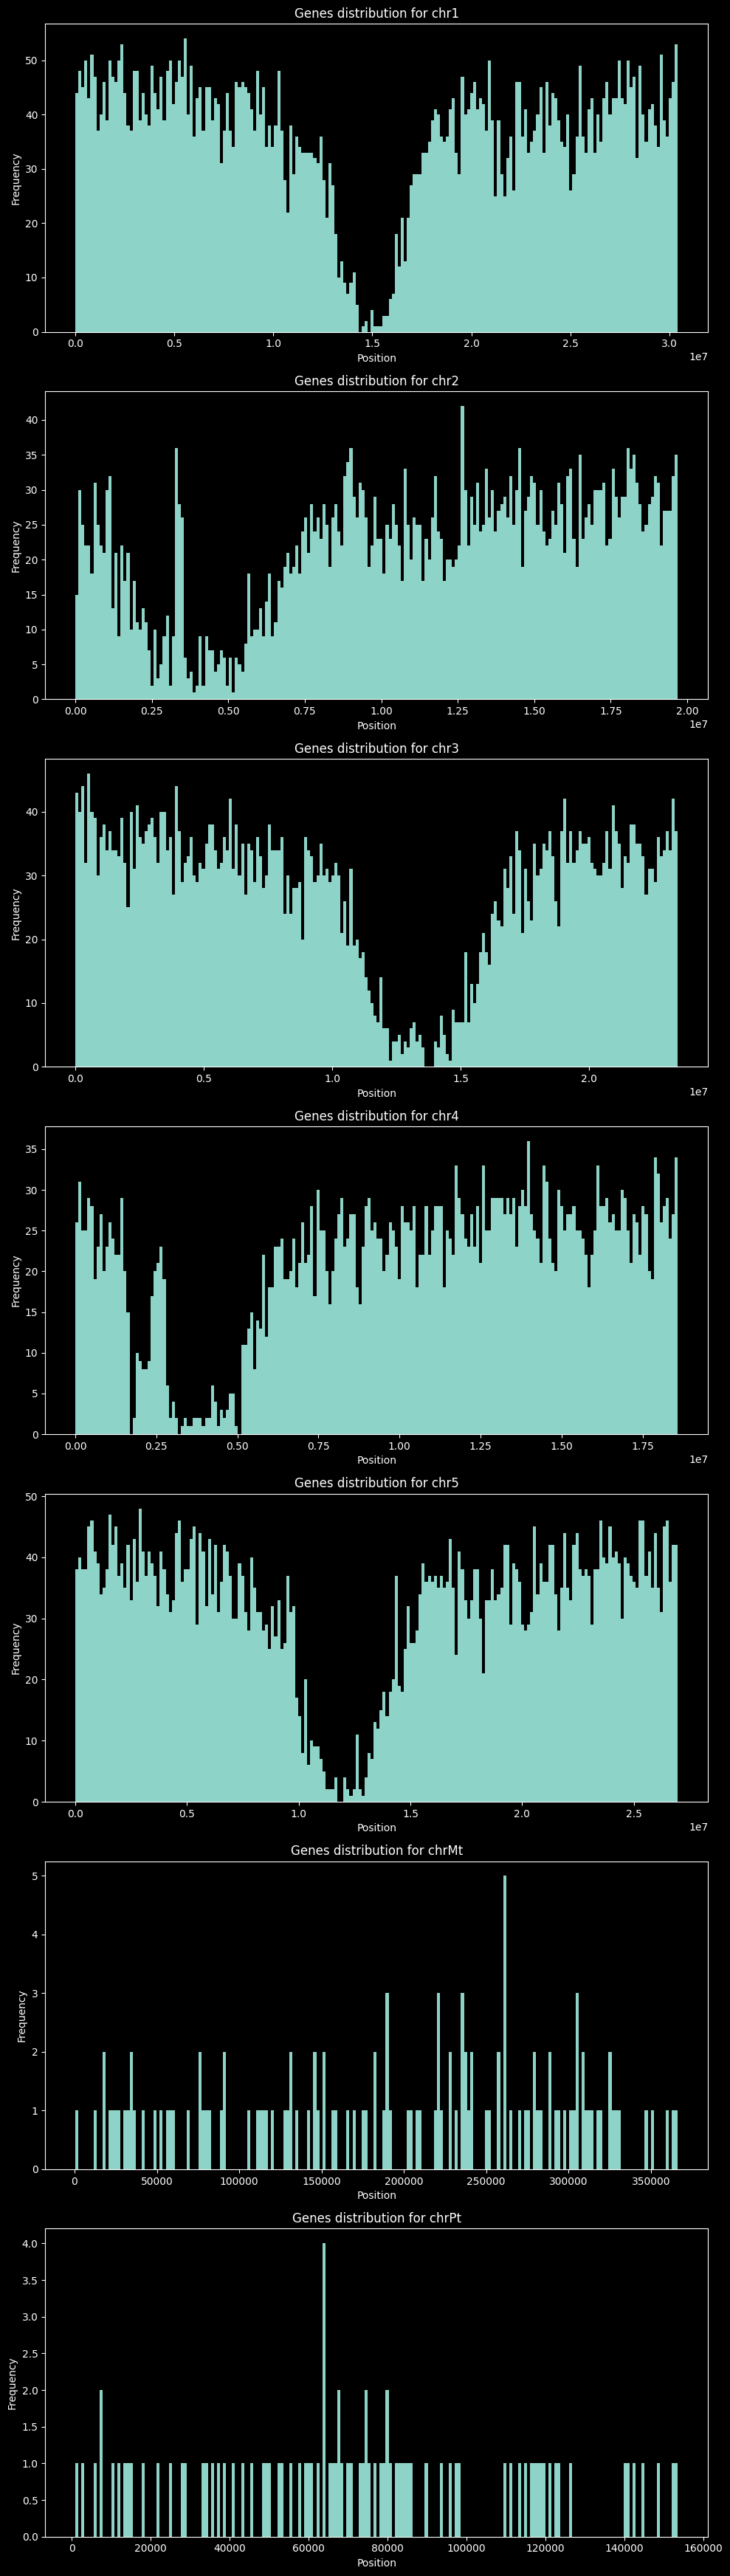

In [18]:
import matplotlib.pyplot as plt

#  Genes distribution for each chromosome
chromosomes = genes['chr'].unique()
fig, axes = plt.subplots(len(chromosomes), 1, figsize=(10, 5 * len(chromosomes)))


for ax, chr in zip(axes, chromosomes):
    chr_genes = genes[genes['chr'] == chr]
    genes_pos = (chr_genes['start'] + chr_genes['end'])/ 2
    ax.hist(genes_pos, bins=200)
    ax.set_title(f'Genes distribution for {chr}')
    ax.set_xlabel('Position')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

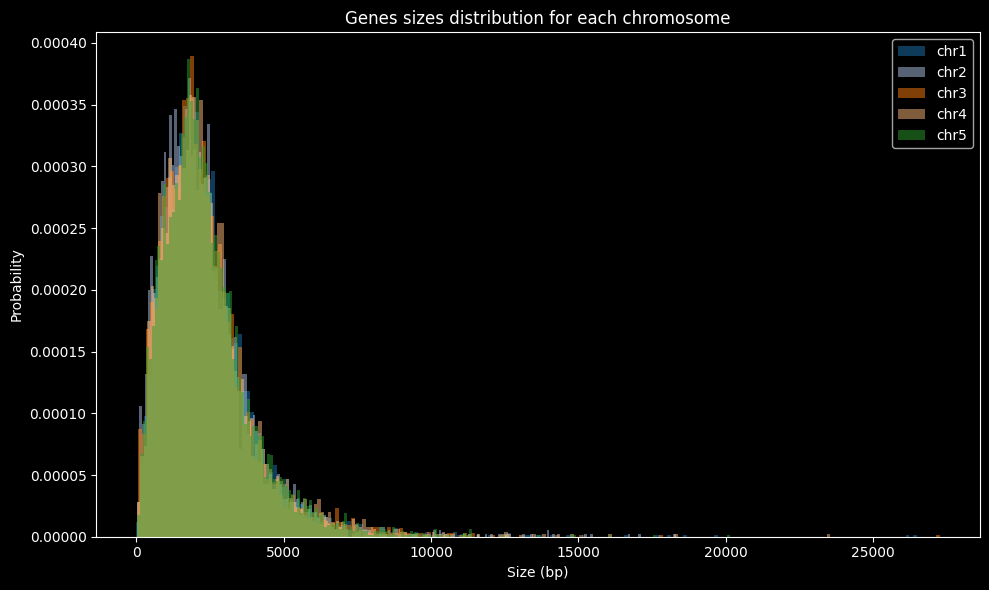

In [23]:
import matplotlib.pyplot as plt

# Genes size distribution for each chromosome
chromosomes = genes['chr'].unique()
fig, ax = plt.subplots(figsize=(10, 6))

# Color palette
colors = plt.cm.tab20.colors

for i, chr in enumerate(chromosomes[:-2]):
    chr_genes = genes[genes['chr'] == chr]
    gene_sizes = (chr_genes['end'] - chr_genes['start'])
    ax.hist(gene_sizes, bins=200, alpha=0.5, label=f'{chr}', color=colors[i % len(colors)], density=True)

ax.set_title('Genes sizes distribution for each chromosome')
ax.set_xlabel('Size (bp)')
ax.set_ylabel('Probability')
ax.legend()

plt.tight_layout()
plt.show()

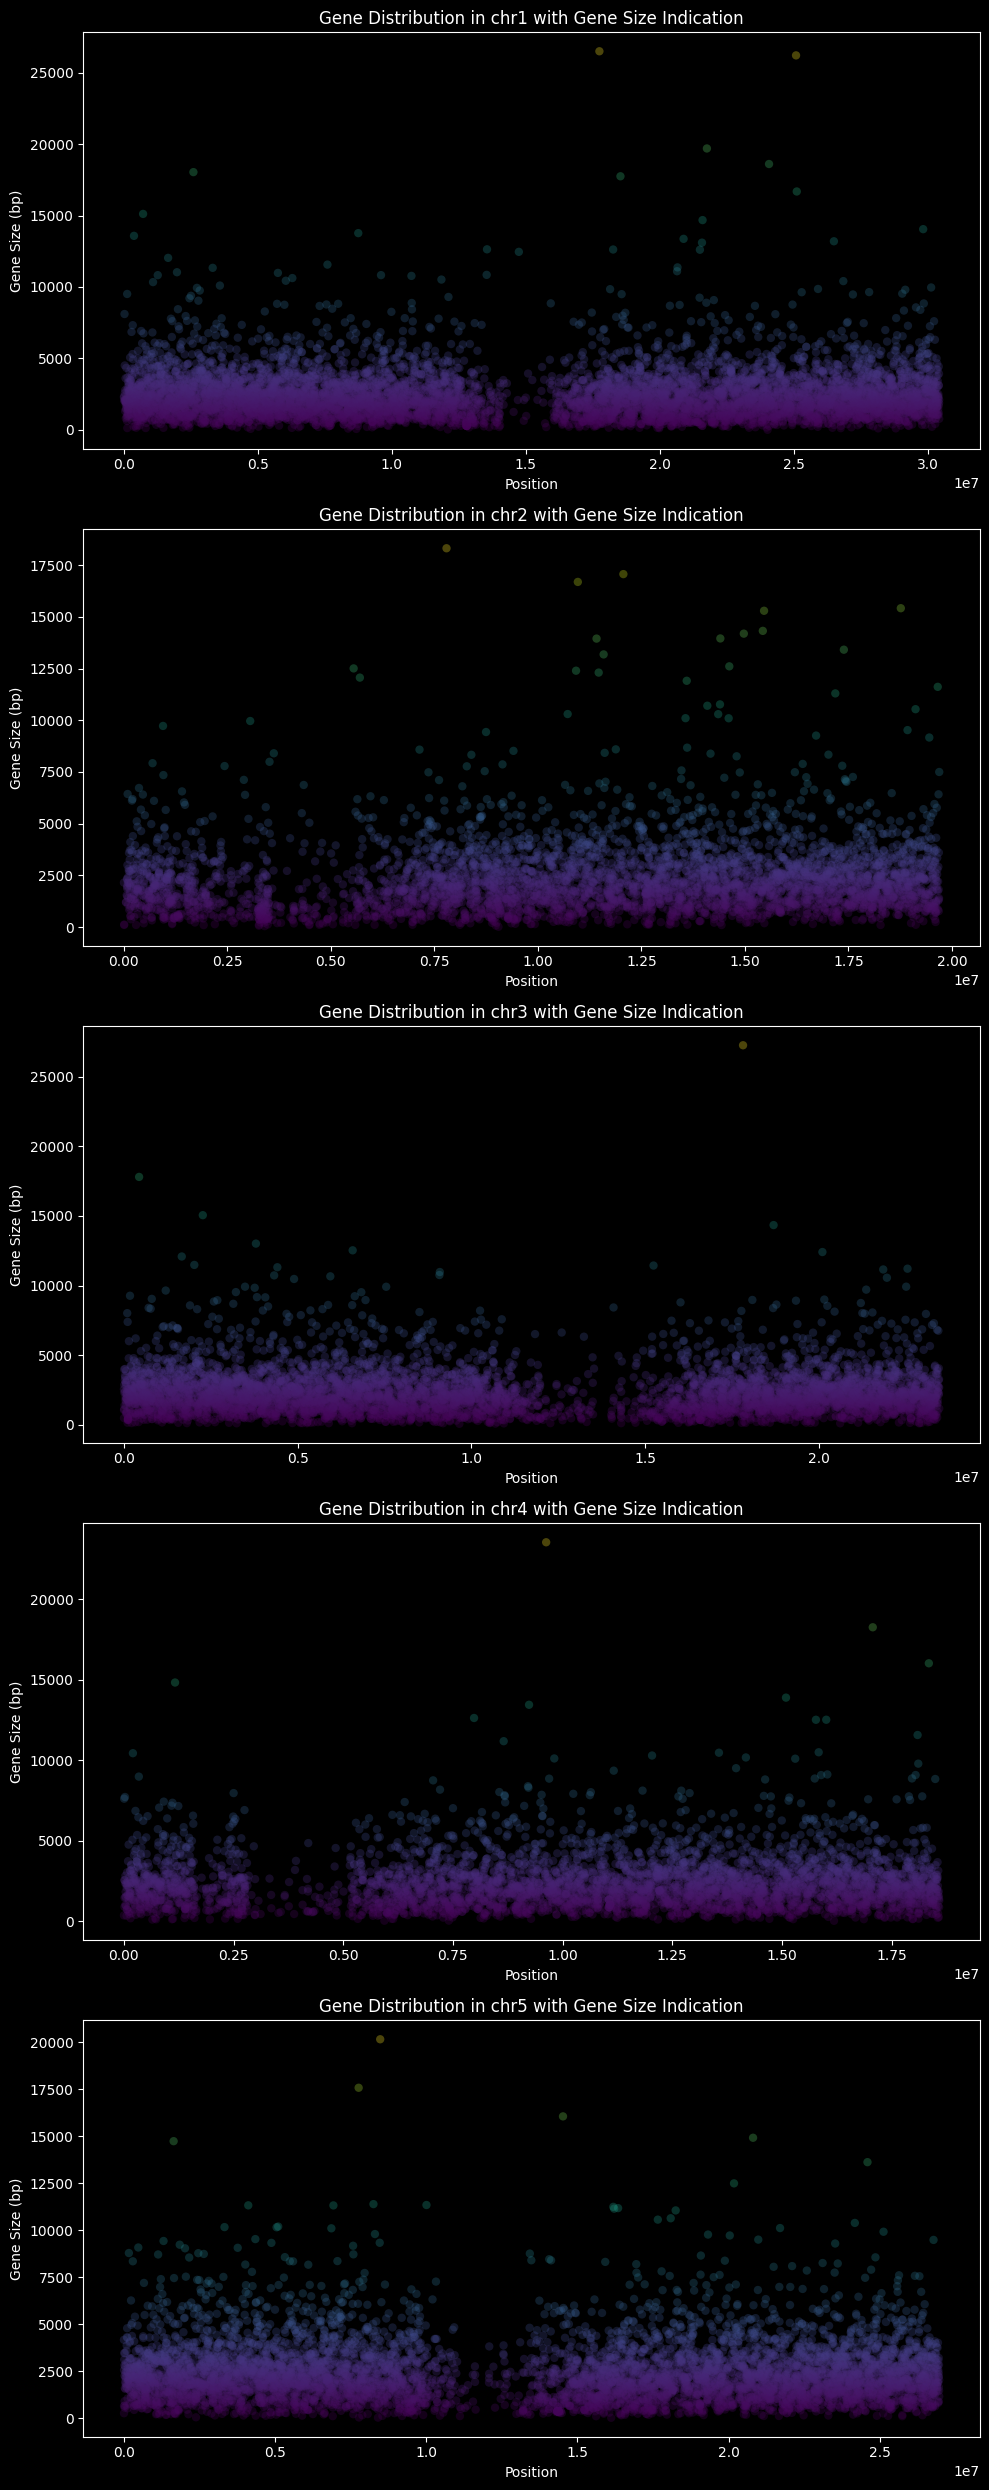

In [37]:
#  Genes distribution and size for each chromosome
chromosomes = genes['chr'].unique()[:-2]
fig, axes = plt.subplots(len(chromosomes), 1, figsize=(10, 5 * len(chromosomes)))


for ax, chr in zip(axes, chromosomes):
    chr_genes = genes[genes['chr'] == chr].copy()
    chr_genes['gene_size'] = chr_genes['end'] - chr_genes['start']
    ax.scatter((chr_genes['start'] + chr_genes['end']) / 2, chr_genes['gene_size'], 
               c=chr_genes['gene_size'], cmap='viridis', alpha=0.3, edgecolors='w', linewidth=0.0)
    ax.set_title(f'Gene Distribution in {chr} with Gene Size Indication')
    ax.set_xlabel('Position')
    ax.set_ylabel('Gene Size (bp)')

plt.tight_layout()
plt.show()

In [65]:
# Filtrar solo las filas duplicadas
duplicate_rows = df[df.duplicated()]

# Verificar el resultado
print(duplicate_rows)

Empty DataFrame
Columns: [chr, source, type, start, end, score, strand, phase, attributes]
Index: []


In [102]:
genes = genes.sort_values(by = ['chr','start'])
df = df.sort_values(by = ['chr','start'])

chr = 'chr1'
chr_genes = genes[genes['chr'] == chr]
chr_genes = chr_genes.reset_index(drop=True)
chr_df = df[df['chr'] == chr]
chr_df = chr_df.reset_index(drop=True)

max_idx  = chr_genes.index[-1]-1

idx = min(18000, max_idx)
inter_gene = chr_df[(chr_df['start'] > chr_genes.iloc[idx]['end']) 
                    & (chr_df['end'] < chr_genes.iloc[idx +1]['start'])]
inter_gene_len = chr_genes.iloc[idx +1]['start'] - chr_genes.iloc[idx]['end']

print(f"inter gen length: {inter_gene_len}")
inter_gene['type'].value_counts()

inter gen length: 269


Series([], Name: count, dtype: int64)

In [7]:
# get the intergenic structures 
intergenic_structs = pd.DataFrame(columns=['chr', 'start', 'end', 'type', 'strand', 'attributes'])

chr = 'chr1'
chr_genes = genes[genes['chr'] == chr]
chr_genes = chr_genes.sort_values(by='start')
chr_genes = chr_genes.reset_index(drop=True)
chr_df = df[df['chr'] == chr]
chr_df = chr_df.sort_values(by='start')
chr_df = chr_df.reset_index(drop=True)

max_idx  = chr_genes.index[-1]-1

for idx in range(max_idx):
    chr_genes_i = chr_genes.iloc[idx]
    chr_genes_j = chr_genes.iloc[idx + 1]
    
    inter_gene = chr_df[(chr_df['start'] > chr_genes_i['end']) 
                        & (chr_df['end'] < chr_genes_j['start'])
                        & (chr_genes_i['end'] + 1< chr_genes_j['start']) # ensure that the genes are not overlapping
                        ]
    if 'CDS' in inter_gene['type'].value_counts():
        continue

    intergenic_structs = pd.concat([intergenic_structs, inter_gene])

intergenic_structs['type'].value_counts()

type
exon               1343
ncRNA_gene          946
lnc_RNA             554
tRNA                223
miRNA                63
ncRNA                63
snoRNA               52
snRNA                12
five_prime_UTR        7
three_prime_UTR       3
Name: count, dtype: int64

In [37]:
'CDS' in intergenic_structs['type'].value_counts()

False

In [ ]:
{'ID': 'intergenic_gene:AT1G01040-gene:AT1G01050'}

In [38]:
gene = df[df['attributes'].apply(lambda x: 'gene:AT1G01040' in x.values()) & (df['type']=='gene')]
gene

,chr,source,type,start,end,score,strand,phase,attributes
152,chr1,araport11,gene,23121,31227,.,+,.,"{'ID': 'gene:AT1G01040', 'Name': 'DCL1', 'biot..."


In [39]:
gene_2 = df[df['attributes'].apply(lambda x: 'gene:AT1G01050' in x.values()) & (df['type']=='gene')]
gene_2

,chr,source,type,start,end,score,strand,phase,attributes
245,chr1,araport11,gene,31170,33171,.,-,.,"{'ID': 'gene:AT1G01050', 'Name': 'PPa1', 'biot..."


In [11]:
# get the intergenic intervals

def get_intergenic_intervals(input_df, min_len =1, max_len = 1000000):
    cols = input_df.columns.tolist()
    output_df = pd.DataFrame(columns=cols)
    intergenic_reg = pd.DataFrame(columns=cols) 

    for chr in input_df['chr'].unique():
        chr_df = input_df[input_df['chr'] == chr]
        chr_df = chr_df.sort_values(by='start')
        chr_df = chr_df.reset_index(drop=True)
        chr_genes = chr_df[chr_df['type'] == 'gene']
        chr_genes = chr_genes.sort_values(by='start')
        chr_genes = chr_genes.reset_index(drop=True)

        max_idx  = chr_genes.index[-1]-1

        for idx in range(max_idx):
            
            start = chr_genes.iloc[idx]['end']+1
            end = chr_genes.iloc[idx + 1]['start']-1

            # ensure that the genes are not overlapping
            # neither concatenated
            if end - start > min_len and end - start < max_len:
                intergenic_structs = chr_df[(chr_df['start'] > start-1) 
                                    & (chr_df['end'] < end+1)                            
                                    ]
                if 'CDS' in intergenic_structs['type'].value_counts():
                    continue

                id_pre = chr_genes.iloc[idx]['attributes']['ID']
                id_post = chr_genes.iloc[idx + 1]['attributes']['ID']
                intergenic_reg.loc[0] = [chr, 
                                        chr_genes.iloc[idx]['source'], 
                                        'intergenic', 
                                        chr_genes.iloc[idx]['end']+1, 
                                        chr_genes.iloc[idx + 1]['start']-1, 
                                        '.', '.', '.', 
                                        {'ID': f'intergenic_{id_pre}-{id_post}'}]
                output_df = pd.concat([output_df, intergenic_reg])
                output_df = pd.concat([output_df, intergenic_structs])

    return output_df

In [6]:
intergenic_df = get_intergenic_intervals(df)

In [12]:
bounded_intergenic_df = get_intergenic_intervals(df, 1000, 3000)

In [7]:
intergenic_df['type'].value_counts()

type
intergenic         23815
exon                4633
ncRNA_gene          3344
lnc_RNA             2073
tRNA                 618
ncRNA                242
miRNA                235
snoRNA               200
three_prime_UTR       64
snRNA                 45
five_prime_UTR        40
rRNA                  15
Name: count, dtype: int64

In [51]:
chr = 'chr1'
chr_intergenic = intergenic_df[(intergenic_df['chr'] == chr) & (intergenic_df['type'] == 'intergenic')]
reg_uni = chr_intergenic[(chr_intergenic['end'] - chr_intergenic['start'])<2]
len(reg_uni)

11

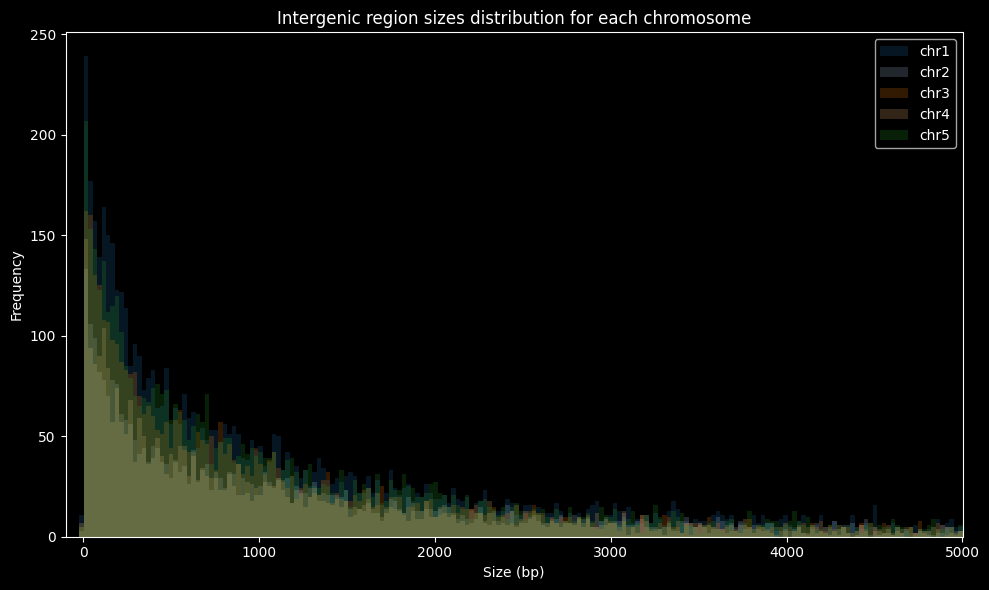

In [8]:
import matplotlib.pyplot as plt

# Intergenic size distribution for each chromosome
chromosomes = intergenic_df['chr'].unique()
fig, ax = plt.subplots(figsize=(10, 6))

# Color palette
colors = plt.cm.tab20.colors
x_range = (-100, 5000)

for i, chr in enumerate(chromosomes[:-2]):
    chr_intergenic = intergenic_df[(intergenic_df['chr'] == chr) & (intergenic_df['type'] == 'intergenic')]
    reg_sizes = (chr_intergenic['end'] - chr_intergenic['start'])
    ax.hist(reg_sizes,range=x_range, bins=200, alpha=0.2, label=f'{chr}', color=colors[i % len(colors)])

ax.set_title('Intergenic region sizes distribution for each chromosome')
ax.set_xlabel('Size (bp)')
ax.set_xlim(x_range)
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

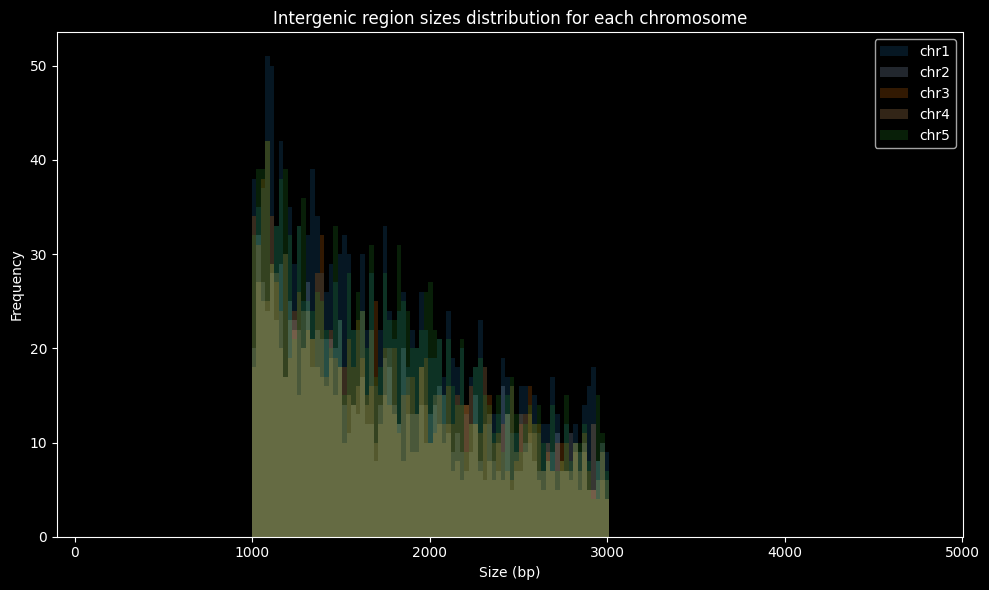

In [13]:
import matplotlib.pyplot as plt

# Intergenic size distribution for each chromosome
chromosomes = bounded_intergenic_df['chr'].unique()
fig, ax = plt.subplots(figsize=(10, 6))

# Color palette
colors = plt.cm.tab20.colors
x_range = (-100, 5000)

for i, chr in enumerate(chromosomes[:-2]):
    chr_intergenic = bounded_intergenic_df[(bounded_intergenic_df['chr'] == chr) & (bounded_intergenic_df['type'] == 'intergenic')]
    reg_sizes = (chr_intergenic['end'] - chr_intergenic['start'])
    ax.hist(reg_sizes,range=x_range, bins=200, alpha=0.2, label=f'{chr}', color=colors[i % len(colors)])

ax.set_title('Intergenic region sizes distribution for each chromosome')
ax.set_xlabel('Size (bp)')
ax.set_xlim(x_range)
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

In [58]:
# Total bounded intergenic regions
bounded_intergenic_df['type'].value_counts()

type
intergenic         6793
exon               1607
ncRNA_gene         1149
lnc_RNA             687
tRNA                173
snoRNA              119
ncRNA                91
miRNA                74
snRNA                21
five_prime_UTR       20
three_prime_UTR      19
rRNA                  2
Name: count, dtype: int64

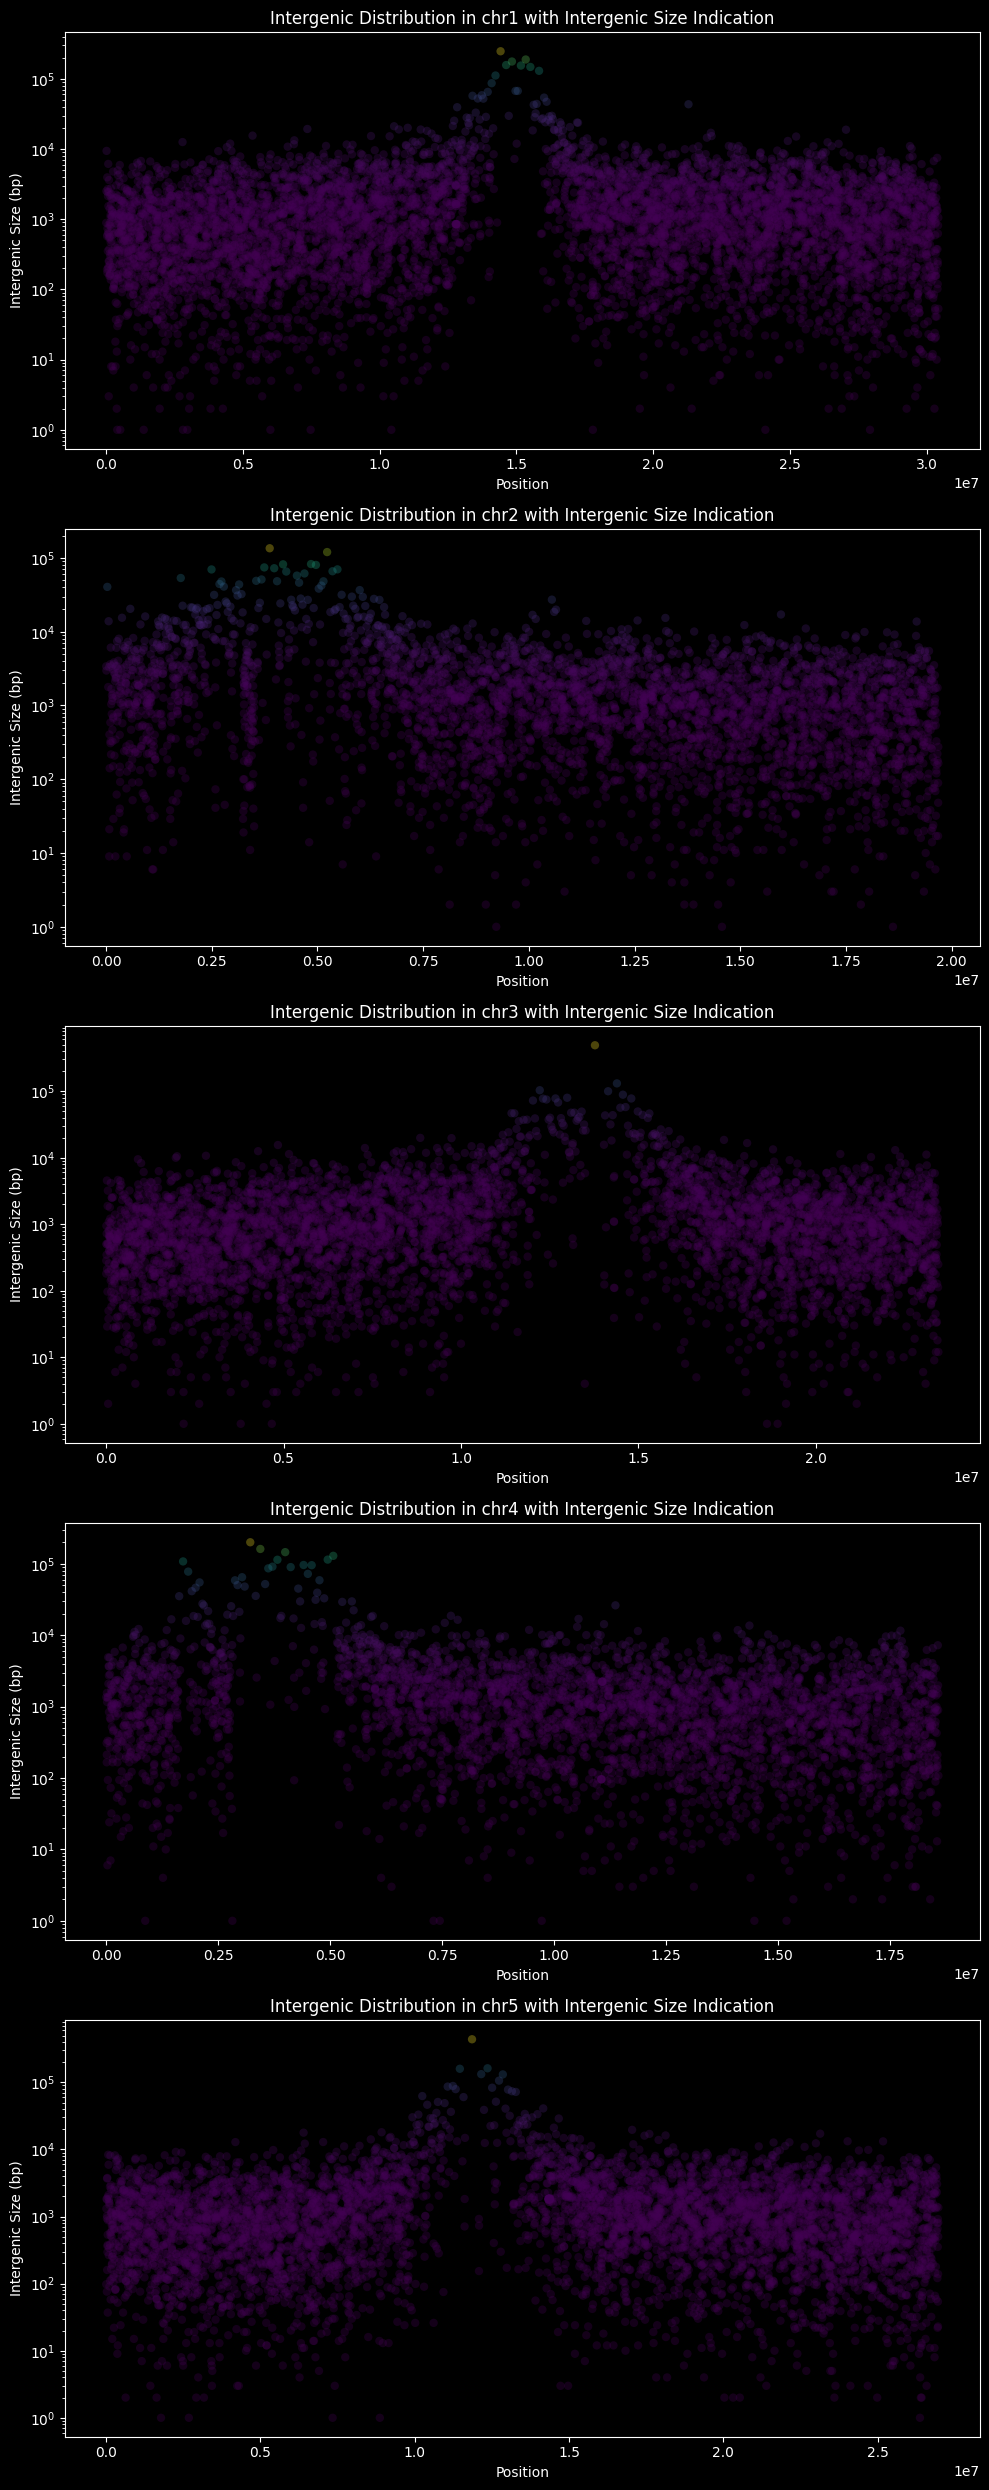

In [10]:
#  Intergenic distribution and size for each chromosome
chromosomes = intergenic_df['chr'].unique()[:-2]
fig, axes = plt.subplots(len(chromosomes), 1, figsize=(10, 5 * len(chromosomes)))


for ax, chr in zip(axes, chromosomes):
    chr_intergenic = intergenic_df[(intergenic_df['chr'] == chr) & (intergenic_df['type'] == 'intergenic')].copy()
    chr_intergenic['intergenic_size'] = chr_intergenic['end'] - chr_intergenic['start']
    ax.scatter((chr_intergenic['start'] + chr_intergenic['end']) / 2, chr_intergenic['intergenic_size'], 
               c=chr_intergenic['intergenic_size'], cmap='viridis', alpha=0.3, edgecolors='w', linewidth=0.0)
    ax.set_title(f'Intergenic Distribution in {chr} with Intergenic Size Indication')
    ax.set_xlabel('Position')
    ax.set_ylabel('Intergenic Size (bp)')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()
    

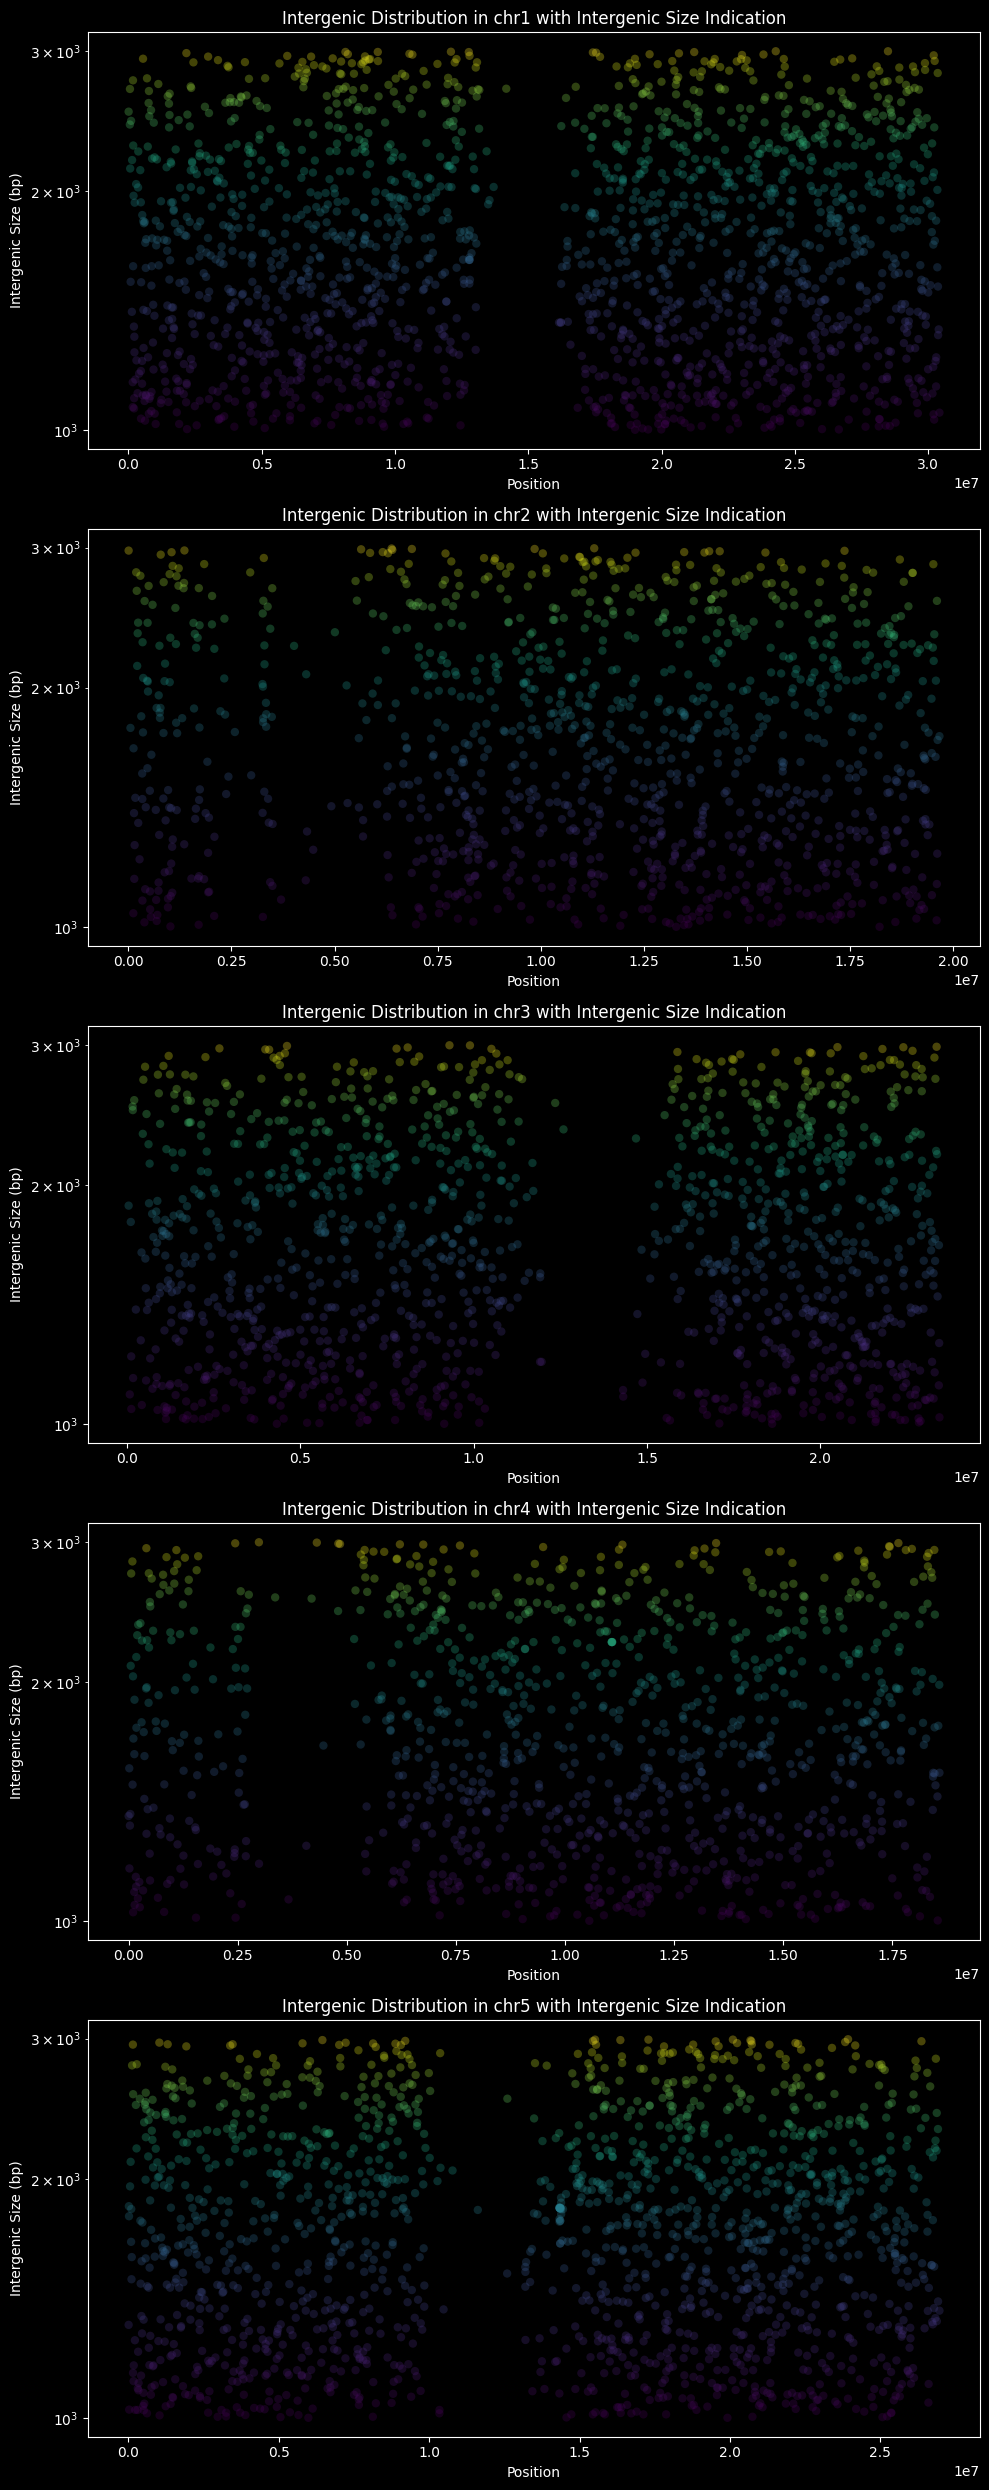

In [14]:
#  Intergenic distribution and size for each chromosome
chromosomes = bounded_intergenic_df['chr'].unique()[:-2]
fig, axes = plt.subplots(len(chromosomes), 1, figsize=(10, 5 * len(chromosomes)))


for ax, chr in zip(axes, chromosomes):
    chr_intergenic = bounded_intergenic_df[(bounded_intergenic_df['chr'] == chr) & (bounded_intergenic_df['type'] == 'intergenic')].copy()
    chr_intergenic['intergenic_size'] = chr_intergenic['end'] - chr_intergenic['start']
    ax.scatter((chr_intergenic['start'] + chr_intergenic['end']) / 2, chr_intergenic['intergenic_size'], 
               c=chr_intergenic['intergenic_size'], cmap='viridis', alpha=0.3, edgecolors='w', linewidth=0.0)
    ax.set_title(f'Intergenic Distribution in {chr} with Intergenic Size Indication')
    ax.set_xlabel('Position')
    ax.set_ylabel('Intergenic Size (bp)')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [10]:
intergenic_CDSs = intergenic_structs[intergenic_structs['type'] == 'CDS']

parents, childrens = find_parents_and_children(intergenic_CDSs.iloc[0], intergenic_structs)
print(parents)

[11608]


In [11]:
intergenic_CDSs.iloc[0]

chr                                                        chr1
start                                                   1060732
end                                                     1060864
type                                                        CDS
strand                                                        +
attributes    ID=CDS:AT1G04100.1;Parent=transcript:AT1G04100...
source                                                araport11
score                                                         .
phase                                                         2
Name: 11607, dtype: object

In [12]:
intergenic_structs.loc[parents]

,chr,start,end,type,strand,attributes,source,score,phase
11608,chr1,1060732,1060864,exon,+,Parent=transcript:AT1G04100.1;Name=AT1G04100.1...,araport11,.,.


In [13]:
parents, childrens = find_parents_and_children(intergenic_structs.loc[11608], df)
print(parents)

[0, 11594, 11595, 11601, 11602]


In [14]:
df.loc[parents]

,chr,source,type,start,end,score,strand,phase,attributes
0,chr1,TAIR10,chromosome,1,30427671,.,.,.,"ID=chromosome:1;Alias=Chr1,CP002684.1,NC_003070.9"
11594,chr1,araport11,gene,1059470,1061209,.,+,.,ID=gene:AT1G04100;Name=IAA10;biotype=protein_c...
11595,chr1,araport11,mRNA,1059470,1061209,.,+,.,ID=transcript:AT1G04100.1;Parent=gene:AT1G0410...
11601,chr1,araport11,exon,1060732,1060864,.,+,.,Parent=transcript:AT1G04100.1;Name=AT1G04100.1...
11602,chr1,araport11,CDS,1060732,1060864,.,+,2,ID=CDS:AT1G04100.1;Parent=transcript:AT1G04100...


In [16]:
parents, childrens = find_parents_and_children(df.loc[11594], df)
df_chil = df.loc[childrens]
df_chil[df_chil['type']== 'gene']


,chr,source,type,start,end,score,strand,phase,attributes
11606,chr1,araport11,gene,1059730,1060348,.,-,.,ID=gene:AT1G04105;Name=AT1G04105;biotype=prote...


## Create `.bed` file from `.gff`

In [44]:
chrs = df['chr'].unique()
chrs[-1]

'chrPt'

In [3]:
import pandas as pd
import random
from pathlib import Path 

class CreateBedFile():
    def __init__(self, 
                 gff_file, 
                 output_file, 
                 labels, 
                 splits = {'train': 0.8, 'val': 0.1, 'test': 0.1}, 
                 min_len = 1, 
                 max_len = 1_000_000, 
                 num_records = 100,
                 shuffle_seed = 42):
        
        gff_file = Path(gff_file)
        assert gff_file.exists(), 'path to gff file must exist'

        self.splits_dict = {}
        for v, k in enumerate(splits.keys()):
            self.splits_dict[k] = v

        self.split_weights = list(splits.values())
        self.min_len = min_len
        self.max_len = max_len
        self.labels = labels
        self.seed = shuffle_seed
        
        self.df = self.gff_to_df(gff_file)
        self.chrs = self.df['chr'].unique() # get the chromosomes
        
        self.df = self.df[(self.df['chr'] != self.chrs[-1])
                          & (self.df['chr'] != self.chrs[-2])] # dropout the mitochondrial and plastid chromosomes
        print('Genome DF created successfully')

        # create the intergenic intervals dataframe
        if 'intergenic' in self.labels:
            self.intergenic_df = self.get_intergenics()
            self.intergenic_df = self.intergenic_df[(self.intergenic_df['type'] == 'intergenic')
                                                    & (self.intergenic_df['chr'] != self.chrs[-1]) 
                                                    & (self.intergenic_df['chr'] != self.chrs[-2])] # dropout the mitochondrial and plastid chromosomes
        print('Intergenic DF created successfully')

        self.num_records = num_records
        self.biotypes = list(set(self.df['type'].unique()) & set(labels))
        self.output_file = output_file

        self.create_bed_file()
        
    def attributes_to_dict(self, attributes):
        attr_dict = {}
        for attribute in attributes.split(';'):
            key_value = attribute.split('=')
            if len(key_value) == 2:
                key, value = key_value
                attr_dict[key] = value
        return attr_dict
    
    def gff_to_df(self, gff_file):
        df = pd.read_csv(gff_file, sep='\t', comment='#', header=None)   
        df.columns = ['chr', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
        df['attributes'] = df['attributes'].apply(self.attributes_to_dict)
        df['chr'] = df['chr'].astype(str)
        df['chr'] = 'Chr' + df['chr']
        print('GFF file read successfully')
        return df
    
    # get the intergenic intervals
    def get_intergenics(self):
        cols = self.df.columns.tolist()
        output_list = []

        for chr in self.df['chr'].unique():
            chr_df = self.df[self.df['chr'] == chr].sort_values(by='start').reset_index(drop=True)
            chr_genes = chr_df[chr_df['type'] == 'gene'].sort_values(by='start').reset_index(drop=True)

            max_idx = chr_genes.index[-1] - 1

            for idx in range(max_idx):
                start = chr_genes.at[idx, 'end'] + 1
                end = chr_genes.at[idx + 1, 'start'] - 1

                # Ensure that the genes are not overlapping or concatenated
                if self.min_len < (end - start) < self.max_len:
                    intergenic_structs = chr_df[(chr_df['start'] > start - 1) & (chr_df['end'] < end + 1)]
                    if 'CDS' in intergenic_structs['type'].value_counts():
                        continue

                    id_pre = chr_genes.at[idx, 'attributes']['ID']
                    id_post = chr_genes.at[idx + 1, 'attributes']['ID']
                    intergenic_row = [chr, 
                                    chr_genes.at[idx, 'source'], 
                                    'intergenic', 
                                    start, 
                                    end, 
                                    '.', '.', '.', 
                                    {'ID': f'intergenic_{id_pre}-{id_post}'}]
                    output_list.append(intergenic_row)
                    output_list.extend(intergenic_structs.values.tolist())

        output_df = pd.DataFrame(output_list, columns=cols)
        return output_df

    def create_bed_file(self):
        splits = list(self.splits_dict.values())
        # Filter the DataFrame to only include the biotypes of interest
        df_filtered = self.df[self.df['type'].isin(self.biotypes)]
        #filter by length in beetwen min_len and max_len
        df_filtered = df_filtered[(df_filtered['end'] - df_filtered['start'] > self.min_len) 
                                  & (df_filtered['end'] - df_filtered['start'] < self.max_len)] 
        # get a sample of the data       
        df_samp = df_filtered.sample(n = self.num_records // 2, replace=False, random_state=self.seed)
        
        if 'intergenic' in self.labels:
            samp_intergenic_df = self.intergenic_df.sample(n = self.num_records // 2, replace=False, random_state=self.seed)
            df_samp = pd.concat([df_samp, samp_intergenic_df])

        # shuffle the data
        df_samp = df_samp.sample(frac=1, replace=False, random_state=self.seed).reset_index(drop=True)

        with open(self.output_file, 'w') as bed_file:
            bed_file.write("chr\tstart\tend\tlabel\tsplit\tstrand\n")            
            for _, row in df_samp.iterrows():
                chr = row['chr']
                start = row['start']
                end = row['end']
                label = row['type']
                split = random.choices(splits, weights = self.split_weights)[0]
                strand = row['strand']
                bed_file.write(f"{chr}\t{start}\t{end}\t{label}\t{split}\t{strand}\n")
        

In [3]:
gff_file = 'data/A.Thaliana/Arabidopsis_thaliana.TAIR10.57.gff3'
output_bed = 'data/A.Thaliana/A.Thaliana.bed'
CreateBedFile(gff_file = gff_file,
                output_file = output_bed,
                labels = ['gene', 'intergenic'],
                min_len = 1000, 
                max_len = 3000,
                num_records = 12000)

/tmp/ipykernel_2146427/573374462.py:59: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(gff_file, sep='\t', comment='#', header=None)


GFF file read successfully
Genome DF created successfully
Intergenic DF created successfully


In [6]:
gff_file = 'data/A.Thaliana/Arabidopsis_thaliana.TAIR10.57.gff3'
output_bed = 'testing_2.bed'
CreateBedFile(gff_file = gff_file,
                output_file = output_bed,
                labels = ['gene', 'intergenic'],
                min_len = 1000, 
                max_len = 3000,
                num_records = 100)

/tmp/ipykernel_3115952/2780557169.py:60: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(gff_file, sep='\t', comment='#', header=None)


GFF file read successfully
Genome DF created successfully
Intergenic DF created successfully


In [4]:
# Read the bed file into a pandas DataFrame 
bed_df = pd.read_csv(output_bed, sep='\t')

# Display statistics about the bed file
print(bed_df.head())
print(bed_df['label'].value_counts(normalize=True))
print(bed_df['split'].value_counts(normalize=True))


    chr     start       end label  split strand
0  Chr1  26503961  26506672  gene      0      -
1  Chr5   8867797   8869862  gene      0      -
2  Chr4  16379603  16381449  gene      0      -
3  Chr1  25693449  25696250  gene      0      +
4  Chr3   2926042   2928569  gene      1      +
label
gene          0.5
intergenic    0.5
Name: proportion, dtype: float64
split
0    0.800250
2    0.102833
1    0.096917
Name: proportion, dtype: float64


In [62]:
# Split statistics for intergenic regions
bed_df[bed_df['label'] == 'intergenic']['split'].value_counts(normalize=True)

split
0    0.797667
1    0.101167
2    0.101167
Name: proportion, dtype: float64

In [63]:
# Split statistics for genes
bed_df[bed_df['label'] == 'gene']['split'].value_counts(normalize=True)

split
0    0.802000
2    0.102667
1    0.095333
Name: proportion, dtype: float64

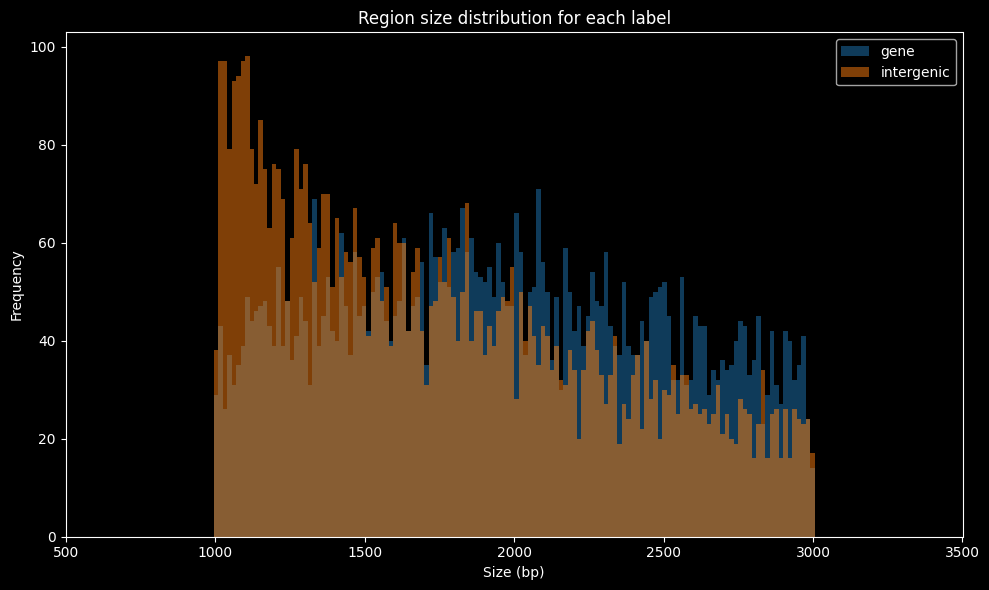

In [6]:
import matplotlib.pyplot as plt
# Plot region size distribution by label
bed_df['region_size'] = bed_df['end'] - bed_df['start']

fig, ax = plt.subplots(figsize=(10, 6))

# Color palette
colors = plt.cm.tab10.colors
x_range = (500, 3500)

for i, l in enumerate(list(bed_df['label'].unique())):
    label_df = bed_df[bed_df['label'] == l]
    reg_sizes = label_df['region_size']
    ax.hist(reg_sizes,range=x_range, bins=200, alpha=0.5, label=f'{l}', color=colors[i % len(colors)])

ax.set_title('Region size distribution for each label')
ax.set_xlabel('Size (bp)')
ax.set_xlim(x_range)
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()


In [93]:
str.join('', random.choices(['A', 'C', 'G', 'T'], k=10))

'ATGACCACCT'